# Linear Regression as a Neural Network
This notebook introduces linear regression as a simple neural network and demonstrates how it can be fitted using gradient descent. We'll go through: 
- Data generation
- Visualisation
- Defining the model
- Loss function
- Gradient Descent algorithm
- Fitting the model and plotting convergence
- Manual training loop in Python


In [72]:
import numpy as np
import matplotlib.pyplot as plt


## Generate a simple dataset

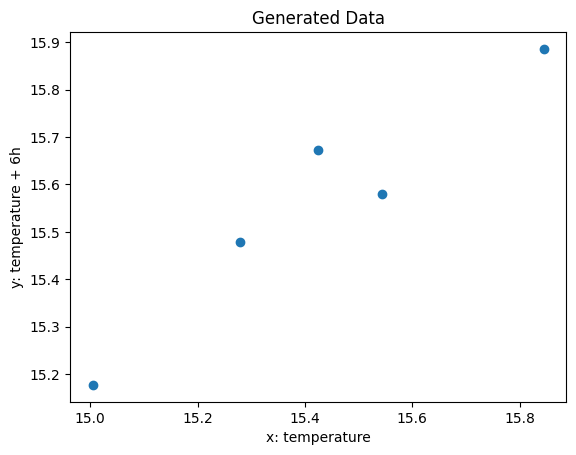

x: temperature [15.54 15.28 15.42 15.84 15.  ]
y: temperature + 6h [15.58 15.48 15.67 15.89 15.18]


In [73]:
np.random.seed(100)
X = 15 + np.random.rand(5, 1)
y = X + np.random.rand(5, 1) * 0.3
plt.scatter(X, y)
plt.xlabel('x: temperature')
plt.ylabel('y: temperature + 6h')
plt.title('Generated Data')
plt.show()
print("x: temperature", np.round(X.flatten(), 2))
print("y: temperature + 6h", np.round(y.flatten(), 2))

We want to use the equation: y = b + w * X + e
We will choose some values of b and w and look at the values of the residual sum of squares

In [74]:
b = 1
w = 1
sum_of_squares = np.sum((y - (b + w * X)) ** 2)
print(f"Residual sum of squares for b={b}, w={w}: {sum_of_squares:.2f}")
b = 5
w = 0.5
sum_of_squares = np.sum((y - (b + w * X)) ** 2)
print(f"Residual sum of squares for b={b}, w={w}: {sum_of_squares:.2f}")


Residual sum of squares for b=1, w=1: 3.74
Residual sum of squares for b=5, w=0.5: 40.65


## Linear Model
We model the line as $y = wX + b$

In [75]:
def predict(X, w, b):
    return w * X + b

## Loss Function: Mean Squared Error

In [76]:
def rmse(y_true, y_pred):
    return np.sqrt(((y_true - y_pred)**2).mean())

## Gradient Descent Step

In [77]:
def compute_gradients(X, y, w, b):
    y_pred = predict(X, w, b)
    error = y_pred - y
    dw = (2 * (error * X).mean())
    db = (2 * error.mean())
    return dw, db

## Training the Model using Gradient Descent

In [78]:
w, b = 2.0, 2.0
lr = 0.001
epochs = 10
losses = []
weights = []
biases = []

for epoch in range(epochs):
    dw, db = compute_gradients(X, y, w, b)
    w -= lr * dw
    b -= lr * db
    loss = rmse(y, predict(X, w, b))
    print(f'Epoch {epoch}, Loss: {loss:.4f}, w: {w:.4f}, b: {b:.4f}')
    losses.append(loss)
    weights.append(w)
    biases.append(b)

Epoch 0, Loss: 9.0277, w: 1.4669, b: 1.9654
Epoch 1, Loss: 4.7160, w: 1.1885, b: 1.9474
Epoch 2, Loss: 2.4641, w: 1.0431, b: 1.9380
Epoch 3, Loss: 1.2885, w: 0.9671, b: 1.9330
Epoch 4, Loss: 0.6757, w: 0.9274, b: 1.9305
Epoch 5, Loss: 0.3579, w: 0.9067, b: 1.9291
Epoch 6, Loss: 0.1962, w: 0.8959, b: 1.9284
Epoch 7, Loss: 0.1186, w: 0.8902, b: 1.9281
Epoch 8, Loss: 0.0859, w: 0.8873, b: 1.9279
Epoch 9, Loss: 0.0746, w: 0.8857, b: 1.9278


## Plotting the Fit

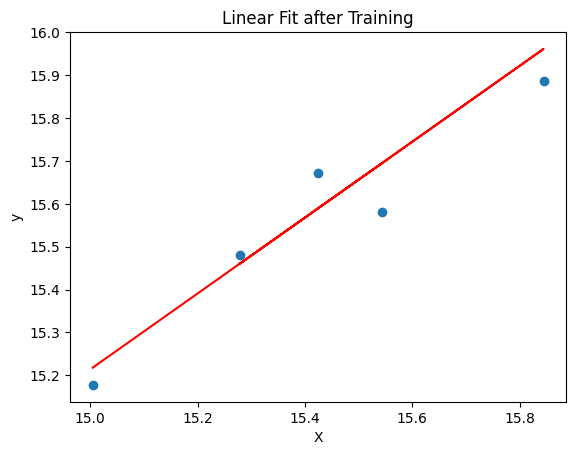

In [79]:
plt.scatter(X, y)
plt.plot(X, predict(X, w, b), color='red')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Fit after Training')
plt.show()

## Loss Curve

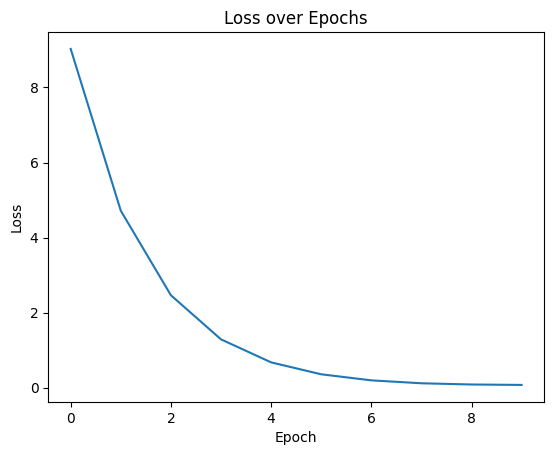

In [80]:
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.show()

## Parameter trajectory
Look at how the parameters have moved in space


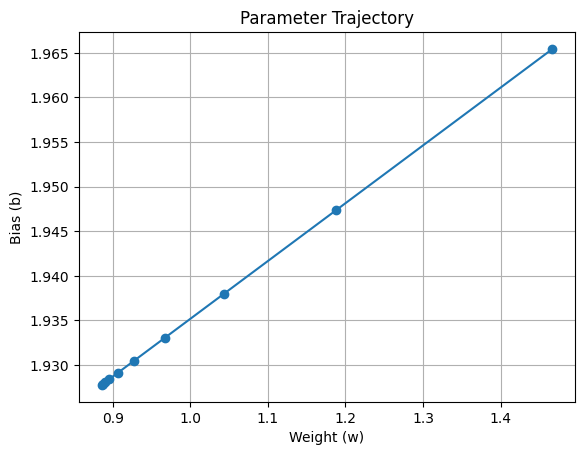

In [81]:
plt.plot(weights, biases, marker='o')
plt.xlabel('Weight (w)')
plt.ylabel('Bias (b)')
plt.title('Parameter Trajectory')
plt.grid()
plt.show()

## Loss Surface Visualization
This contour plot shows the loss 'landscape'. The x-axis is the weight ($w$), the y-axis is the bias ($b$), and the color represents the value of the loss function. The white line shows the path taken by Gradient Descent.

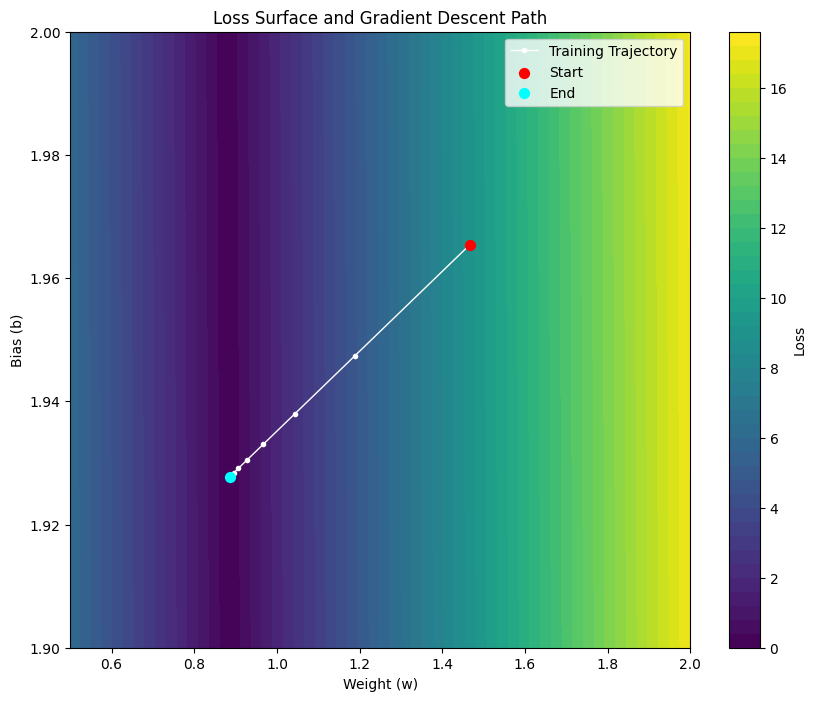

In [84]:
# Create a grid of weights and biases
w_range = np.linspace(0.5, 2, 100)
b_range = np.linspace(1.9, 2, 100)
W, B = np.meshgrid(w_range, b_range)
Z = np.zeros(W.shape)

# Calculate loss for each point on the grid
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        Z[i, j] = rmse(y, predict(X, W[i, j], B[i, j]))

# Plotting the contour
plt.figure(figsize=(10, 8))
cp = plt.contourf(W, B, Z, levels=50, cmap='viridis')
plt.colorbar(cp, label='Loss')

# Plot the trajectory of the weights and biases
plt.plot(weights, biases, color='white', marker='o', markersize=3, linewidth=1, label='Training Trajectory')
plt.scatter(weights[0], biases[0], color='red', s=50, label='Start', zorder=5)
plt.scatter(weights[-1], biases[-1], color='cyan', s=50, label='End', zorder=5)

plt.xlabel('Weight (w)')
plt.ylabel('Bias (b)')
plt.title('Loss Surface and Gradient Descent Path')
plt.legend()
plt.show()

## Try it Yourself!
Try changing the learning rate or number of epochs and see how it affects convergence.